# Capstone Assignment 20.1: Initial Report and Exploratory Data Analysis (EDA)

## Diamond Price Analysis & Prediction

**Author:** Arun Elumalai  
**Program:** UC Berkeley Professional Certificate in Machine Learning & Artificial Intelligence  
**Assignment:** Capstone 20.1 — Initial Report and Exploratory Data Analysis  

---

## Executive Summary

This project analyzes diamond pricing to understand the key physical and quality factors that determine diamond market value. Using the Diamonds dataset (53,940 records, 9 features), we perform a comprehensive Exploratory Data Analysis (EDA) to uncover distribution patterns, feature correlations, and the influence of grading characteristics on price.

Our analysis reveals that **carat weight** is the dominant predictor of price (r = 0.92), while the **4Cs grading attributes** (Cut, Color, Clarity) also significantly influence value — sometimes counter-intuitively when carat weight is not controlled for. A baseline **Linear Regression** model on log-transformed data achieves an R² of ~0.92, establishing a strong foundation for advanced modeling in subsequent capstone stages.

---


## Table of Contents

1. [Problem Statement & Rationale](#1-problem-statement--rationale)
2. [Research Question](#2-research-question)
3. [Data Sources](#3-data-sources)
4. [Setup & Imports](#4-setup--imports)
5. [Data Loading & Initial Overview](#5-data-loading--initial-overview)
6. [Data Cleaning & Preprocessing](#6-data-cleaning--preprocessing)
7. [Exploratory Data Analysis (EDA)](#7-exploratory-data-analysis-eda)
   - 7.1 [Univariate Analysis — Distributions](#71-univariate-analysis--distributions)
   - 7.2 [Bivariate Analysis — Feature vs Price](#72-bivariate-analysis--feature-vs-price)
   - 7.3 [Correlation Analysis](#73-correlation-analysis)
   - 7.4 [Categorical Feature Analysis — The 4Cs](#74-categorical-feature-analysis--the-4cs)
   - 7.5 [Price Distributions by Quality Grades](#75-price-distributions-by-quality-grades)
   - 7.6 [Outlier Analysis](#76-outlier-analysis)
8. [Key Findings & Insights](#8-key-findings--insights)
9. [Baseline Model](#9-baseline-model)
10. [Next Steps](#10-next-steps)


## 1. Problem Statement & Rationale

The global diamond market is valued at over \$80 billion annually, with pricing driven by a complex interaction of physical attributes and quality grades assessed by gemological experts. Accurately predicting diamond prices has significant value for:

- **Consumers**: Making informed purchasing decisions and negotiating fair prices.
- **Retailers & Dealers**: Setting competitive prices and managing inventory valuation.
- **Insurance Companies**: Providing accurate replacement value estimates.
- **Investment Platforms**: Evaluating diamonds as alternative assets.

The Diamonds dataset provides a rich, real-world snapshot of 53,940 diamonds graded under the industry-standard **4Cs framework** — Carat, Cut, Color, and Clarity — along with physical dimensions. It offers an ideal setting to demonstrate how EDA and ML can be applied to explain and predict pricing in a complex luxury goods market.

**Why this matters:** Traditional diamond pricing relies on expert appraisers who introduce subjectivity and inconsistency. A data-driven model could provide transparent, reproducible price estimates that democratize access to fair market valuations.


## 2. Research Question

> **"What physical and quality characteristics of a diamond most strongly determine its market price, and can we build a machine learning model to accurately predict diamond prices from these attributes?"**

More specifically, this analysis addresses:

1. Which features (carat, cut, color, clarity, dimensions) most strongly correlate with price?
2. How do the ordinal quality grades (Cut, Color, Clarity) influence price independently of carat weight?
3. Are there non-linear relationships between physical dimensions and price?
4. What baseline model performance can we achieve with Linear Regression?


## 3. Data Sources

| Source | Description | Size |
|--------|-------------|------|
| [Diamonds Dataset (Seaborn / ggplot2)](https://ggplot2.tidyverse.org/reference/diamonds.html) | Classic gemological dataset containing prices and quality attributes of ~54K diamonds | 53,940 rows × 10 columns |

### Feature Descriptions

| Feature | Type | Description | Values |
|---------|------|-------------|--------|
| `carat` | Float | Weight of the diamond | 0.2 — 5.01 ct |
| `cut` | Ordinal | Quality of the cut | Fair, Good, Very Good, Premium, Ideal |
| `color` | Ordinal | Diamond color grade | D (best) → J (worst) |
| `clarity` | Ordinal | Measurement of how clear the diamond is | I1 (worst) → IF (best) |
| `depth` | Float | Total depth percentage = z / mean(x,y) | % |
| `table` | Float | Width of top of diamond relative to widest point | % |
| `x` | Float | Length in mm | mm |
| `y` | Float | Width in mm | mm |
| `z` | Float | Depth in mm | mm |
| `price` | Int | **Target**: Price in USD | \$326 — \$18,823 |


## 4. Setup & Imports


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('figures', exist_ok=True)

print('Libraries loaded successfully.')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version:  {np.__version__}')


Libraries loaded successfully.
Pandas version: 3.0.2
NumPy version:  2.4.4


## 5. Data Loading & Initial Overview


In [2]:
# Load the Diamonds dataset (bundled with Seaborn)
df = sns.load_dataset('diamonds')

print('=' * 60)
print('DIAMONDS DATASET — OVERVIEW')
print('=' * 60)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
print(f'\nTarget variable: price (USD)')


DIAMONDS DATASET — OVERVIEW
Shape: 53,940 rows x 10 columns

Columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

Target variable: price (USD)


In [3]:
# First 5 rows
print('First 5 rows:')
df.head()


First 5 rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.2300,Ideal,E,SI2,61.5000,55.0000,326,3.9500,3.9800,2.4300
1,0.2100,Premium,E,SI1,59.8000,61.0000,326,3.8900,3.8400,2.3100
2,0.2300,Good,E,VS1,56.9000,65.0000,327,4.0500,4.0700,2.3100
3,0.2900,Premium,I,VS2,62.4000,58.0000,334,4.2000,4.2300,2.6300
4,0.3100,Good,J,SI2,63.3000,58.0000,335,4.3400,4.3500,2.7500


In [4]:
# Data types and non-null counts
print('Dataset Info:')
df.info()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [5]:
# Unique values in categorical features
for col in ['cut', 'color', 'clarity']:
    print(f'{col:10} unique values: {df[col].unique().tolist()}')


cut        unique values: ['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
color      unique values: ['E', 'I', 'J', 'H', 'F', 'G', 'D']
clarity    unique values: ['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']


In [6]:
# Statistical summary
print('Statistical Summary (numeric):')
df.describe()


Statistical Summary (numeric):


,carat,depth,table,price,x,y,z
count,53940.0000,53940.0000,53940.0000,53940.0000,53940.0000,53940.0000,53940.0000
mean,0.7979,61.7494,57.4572,3932.7997,5.7312,5.7345,3.5387
std,0.4740,1.4326,2.2345,3989.4397,1.1218,1.1421,0.7057
min,0.2000,43.0000,43.0000,326.0000,0.0000,0.0000,0.0000
25%,0.4000,61.0000,56.0000,950.0000,4.7100,4.7200,2.9100
50%,0.7000,61.8000,57.0000,2401.0000,5.7000,5.7100,3.5300
75%,1.0400,62.5000,59.0000,5324.2500,6.5400,6.5400,4.0400
max,5.0100,79.0000,95.0000,18823.0000,10.7400,58.9000,31.8000


## 6. Data Cleaning & Preprocessing


In [7]:
# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')


Missing values per column:
No missing values found.


In [8]:
# Check for physically impossible zero dimensions
zero_x = (df['x'] == 0).sum()
zero_y = (df['y'] == 0).sum()
zero_z = (df['z'] == 0).sum()
print(f'Rows with x == 0: {zero_x}')
print(f'Rows with y == 0: {zero_y}')
print(f'Rows with z == 0: {zero_z}')

# Check for extreme outliers in y and z
print(f'\nRows with y > 30mm (suspicious): {(df["y"] > 30).sum()}')
print(f'Rows with z > 30mm (suspicious): {(df["z"] > 30).sum()}')
print(f'\nMax y: {df["y"].max():.2f} mm')
print(f'Max z: {df["z"].max():.2f} mm')

# Show the suspicious rows
suspicious = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0) |
                (df['y'] > 30) | (df['z'] > 30)]
print(f'\nSuspicious rows ({len(suspicious)} total):')
print(suspicious)


Rows with x == 0: 8
Rows with y == 0: 7
Rows with z == 0: 20

Rows with y > 30mm (suspicious): 2
Rows with z > 30mm (suspicious): 1

Max y: 58.90 mm
Max z: 31.80 mm

Suspicious rows (23 total):
       carat        cut color clarity   depth   table  price      x       y  \
2207  1.0000    Premium     G     SI2 59.1000 59.0000   3142 6.5500  6.4800   
2314  1.0100    Premium     H      I1 58.1000 59.0000   3167 6.6600  6.6000   
4791  1.1000    Premium     G     SI2 63.0000 59.0000   3696 6.5000  6.4700   
5471  1.0100    Premium     F     SI2 59.2000 58.0000   3837 6.5000  6.4700   
10167 1.5000       Good     G      I1 64.0000 61.0000   4731 7.1500  7.0400   
11182 1.0700      Ideal     F     SI2 61.6000 56.0000   4954 0.0000  6.6200   
11963 1.0000  Very Good     H     VS2 63.3000 53.0000   5139 0.0000  0.0000   
13601 1.1500      Ideal     G     VS2 59.2000 56.0000   5564 6.8800  6.8300   
15951 1.1400       Fair     G     VS1 57.5000 67.0000   6381 0.0000  0.0000   
24067 2.0000    

In [9]:
# Clean the dataset
df_clean = df.copy()

# Remove records with impossible physical dimensions
df_clean = df_clean[(df_clean['x'] > 0) & (df_clean['y'] > 0) & (df_clean['z'] > 0)]
df_clean = df_clean[(df_clean['y'] <= 30) & (df_clean['z'] <= 30)]

print(f'Original dataset size: {len(df):,}')
print(f'Cleaned dataset size:  {len(df_clean):,}')
print(f'Rows removed:          {len(df) - len(df_clean):,} '
      f'({(len(df) - len(df_clean)) / len(df) * 100:.3f}%)')

# Define ordinal ordering for categorical features
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']  # D=best, J=worst
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Add numeric ordinal codes for correlation analysis
df_clean['cut_ord']     = pd.Categorical(df_clean['cut'],     categories=cut_order,     ordered=True).codes
df_clean['color_ord']   = pd.Categorical(df_clean['color'],   categories=color_order,   ordered=True).codes
df_clean['clarity_ord'] = pd.Categorical(df_clean['clarity'], categories=clarity_order, ordered=True).codes

df_clean = df_clean.reset_index(drop=True)
print('\nData cleaning complete.')


Original dataset size: 53,940
Cleaned dataset size:  53,917
Rows removed:          23 (0.043%)

Data cleaning complete.


## 7. Exploratory Data Analysis (EDA)


### 7.1 Univariate Analysis — Distributions


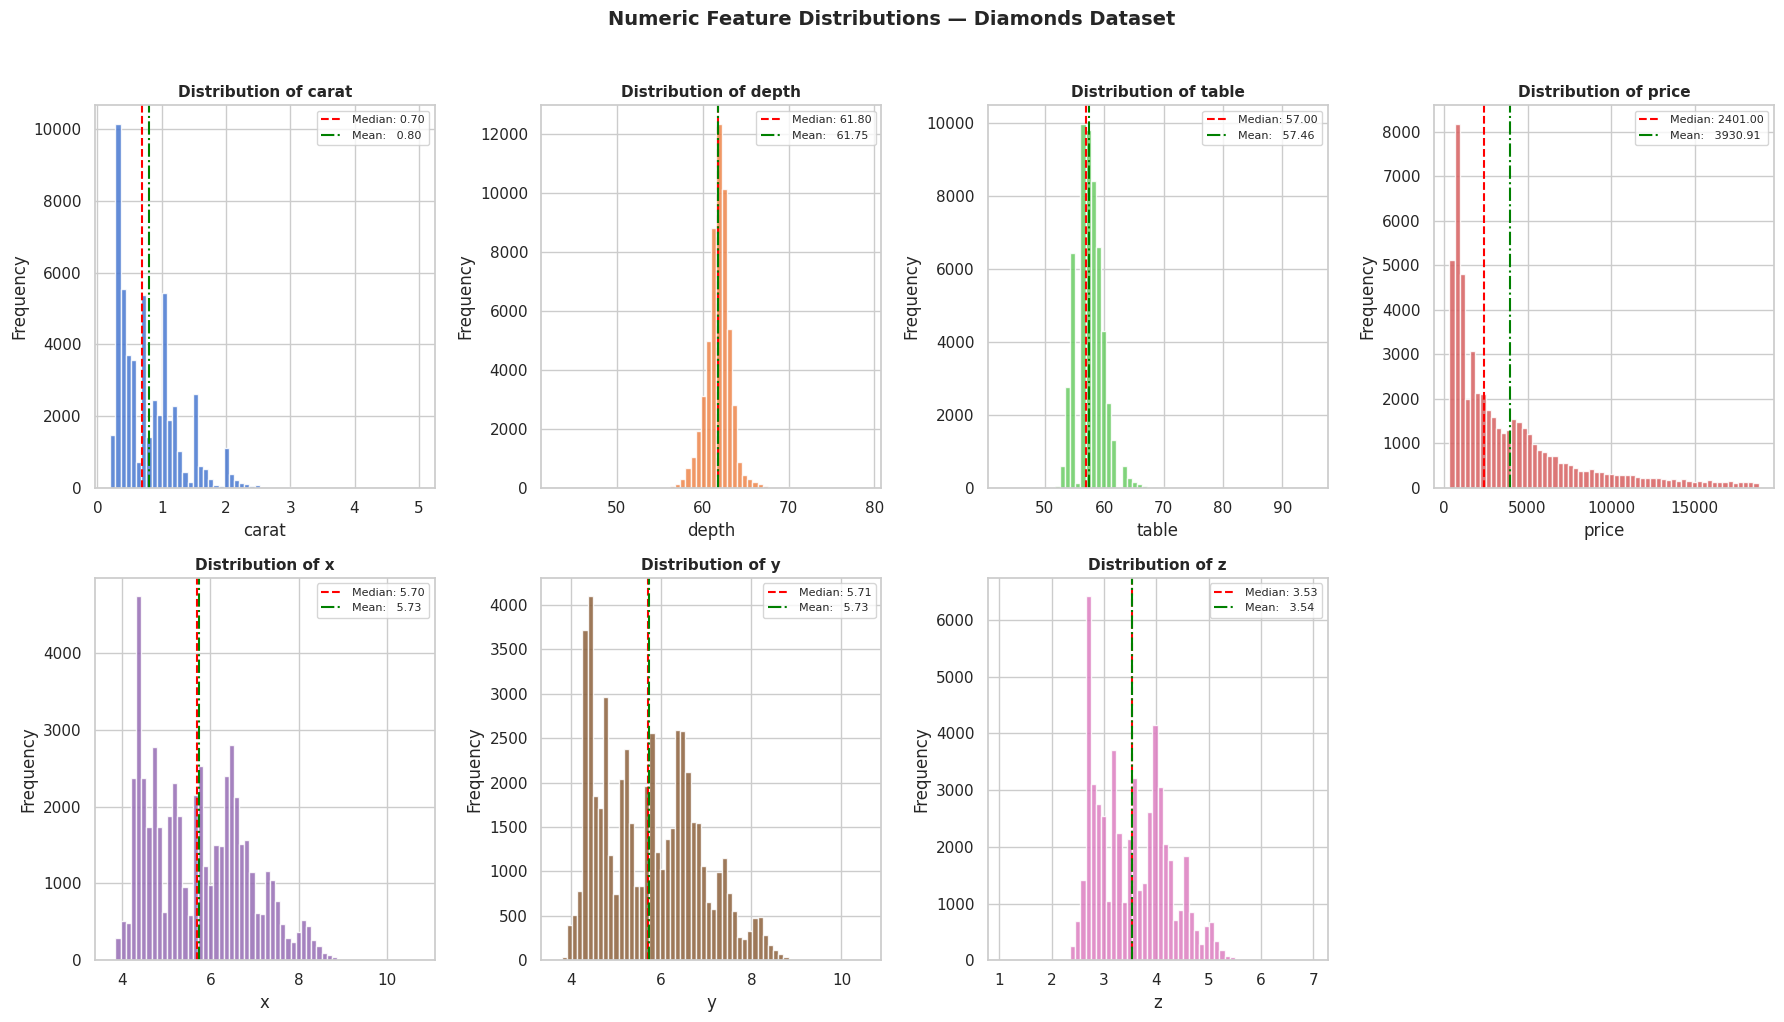

Skewness of numeric features:
  carat   : skew = 1.1162
  depth   : skew = -0.0817
  table   : skew = 0.7968
  price   : skew = 1.6184
  x       : skew = 0.3983
  y       : skew = 0.3927
  z       : skew = 0.3938


In [10]:
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
palette = sns.color_palette('muted', len(numeric_cols))

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_clean[col], bins=60, color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    med = df_clean[col].median()
    mn  = df_clean[col].mean()
    axes[i].axvline(med, color='red',   linestyle='--', linewidth=1.5, label=f'Median: {med:.2f}')
    axes[i].axvline(mn,  color='green', linestyle='-.', linewidth=1.5, label=f'Mean:   {mn:.2f}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)

plt.suptitle('Numeric Feature Distributions — Diamonds Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/01_feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

print('Skewness of numeric features:')
for col in numeric_cols:
    print(f'  {col:<8}: skew = {df_clean[col].skew():.4f}')


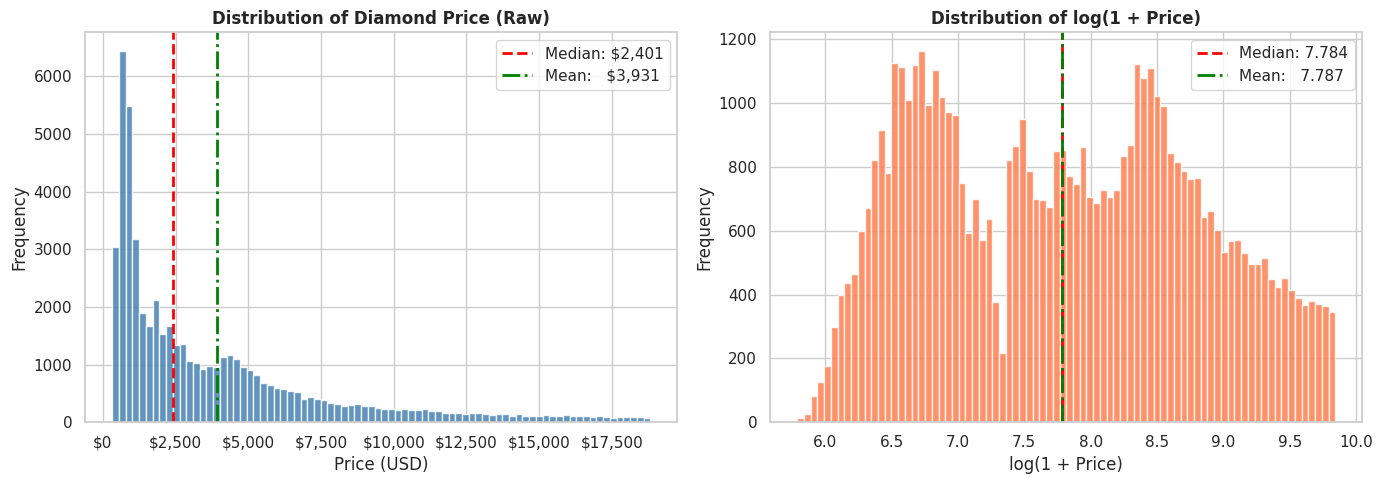

Price skewness (raw):             1.6184
Price skewness (log-transformed): 0.1161
Price range: $326 — $18,823
Median price: $2,401.0


In [11]:
# Log-transform of price vs raw price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price = df_clean['price']
axes[0].hist(price, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Diamond Price (Raw)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].axvline(price.median(), color='red',   linestyle='--', linewidth=2,
                label=f'Median: ${price.median():,.0f}')
axes[0].axvline(price.mean(),   color='green', linestyle='-.', linewidth=2,
                label=f'Mean:   ${price.mean():,.0f}')
axes[0].legend()

log_price = np.log1p(price)
axes[1].hist(log_price, bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of log(1 + Price)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(log_price.median(), color='red',   linestyle='--', linewidth=2,
                label=f'Median: {log_price.median():.3f}')
axes[1].axvline(log_price.mean(),   color='green', linestyle='-.', linewidth=2,
                label=f'Mean:   {log_price.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/02_price_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Price skewness (raw):             {price.skew():.4f}')
print(f'Price skewness (log-transformed): {log_price.skew():.4f}')
print(f'Price range: ${price.min():,} — ${price.max():,}')
print(f'Median price: ${price.median():,}')


### 7.2 Bivariate Analysis — Feature vs Price


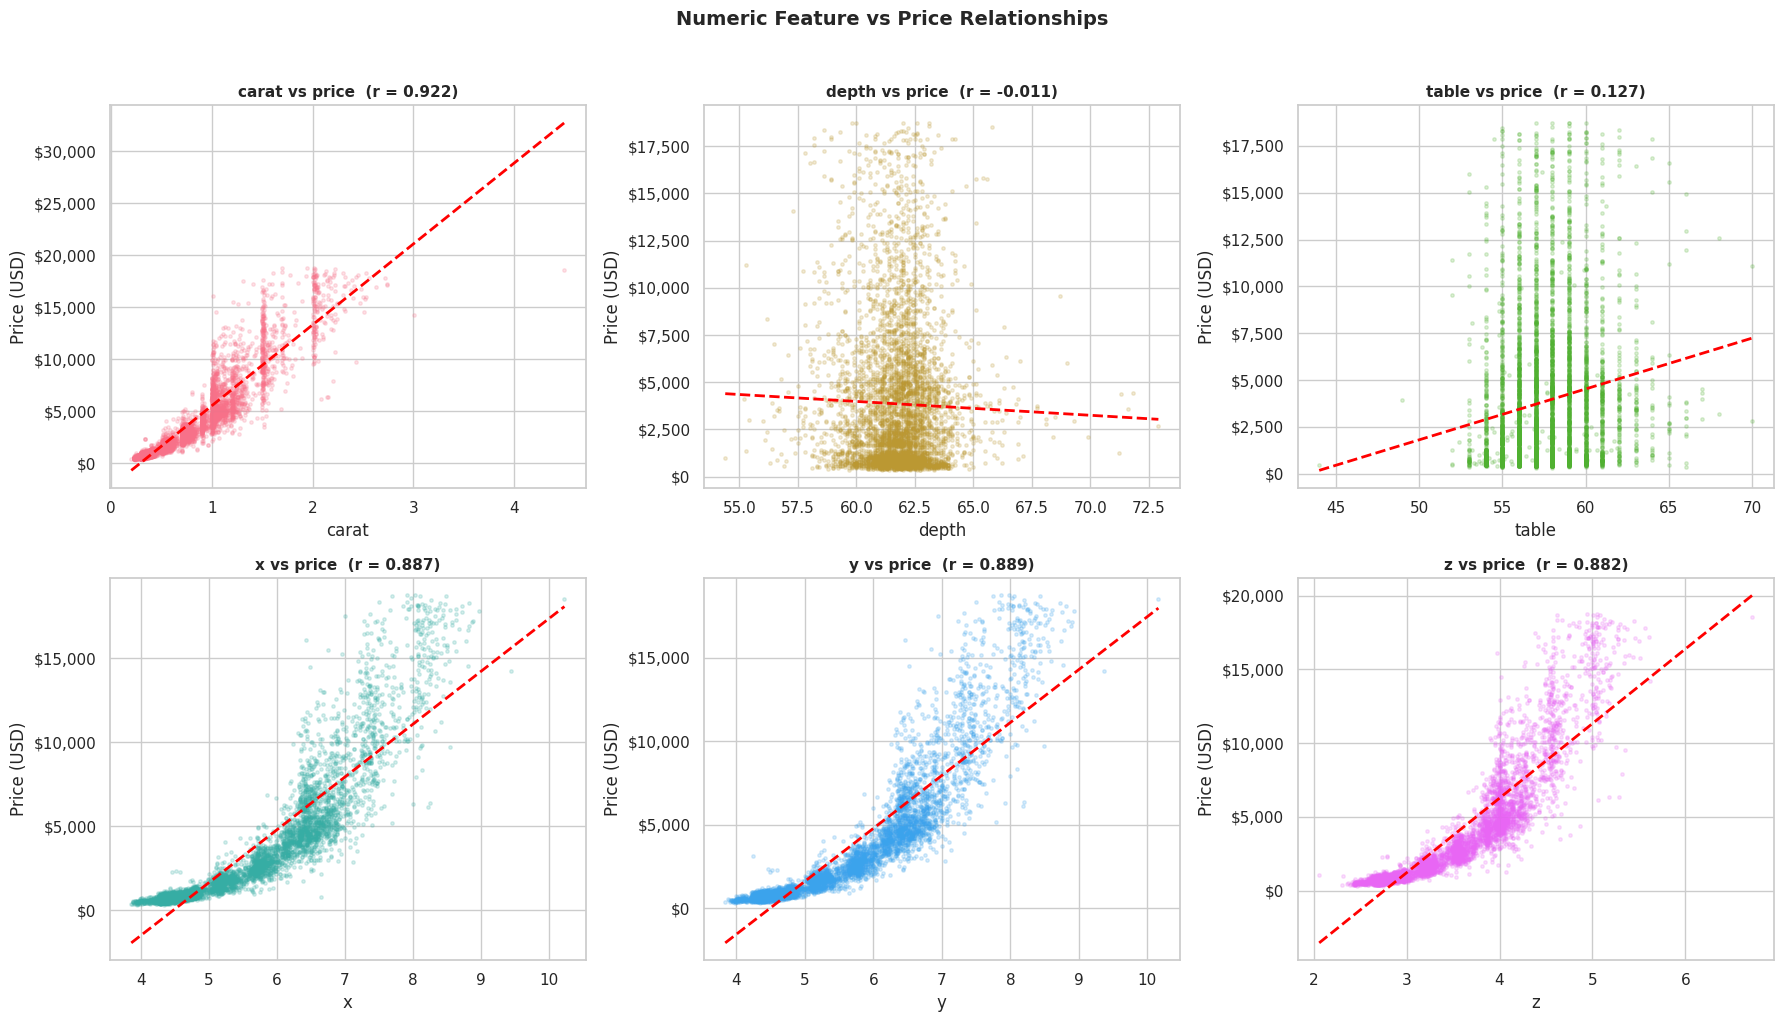

In [12]:
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
palette = sns.color_palette('husl', len(numeric_features))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

sample = df_clean.sample(5000, random_state=42)

for i, col in enumerate(numeric_features):
    axes[i].scatter(sample[col], sample['price'], alpha=0.2, s=6, color=palette[i])

    # Trend line
    z = np.polyfit(sample[col], sample['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[col].min(), sample[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--')

    corr = df_clean[col].corr(df_clean['price'])
    axes[i].set_title(f'{col} vs price  (r = {corr:.3f})',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price (USD)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Numeric Feature vs Price Relationships',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/03_bivariate_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


### 7.3 Correlation Analysis


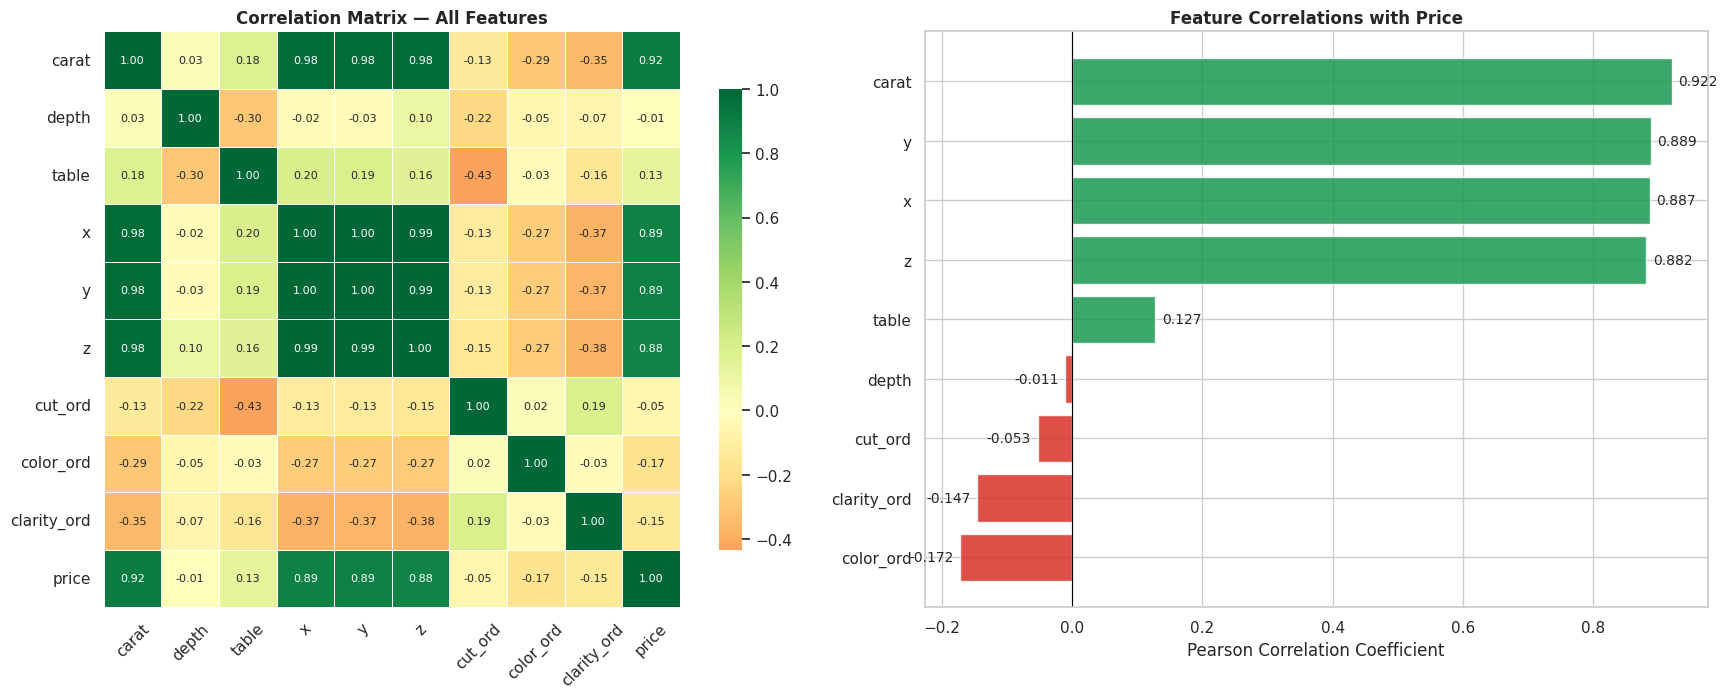

Correlations with price (sorted by absolute value):
  carat          : +0.9216
  y              : +0.8888
  x              : +0.8872
  z              : +0.8821
  color_ord      : -0.1724
  clarity_ord    : -0.1467
  table          : +0.1272
  cut_ord        : -0.0535
  depth          : -0.0107


In [13]:
corr_cols = ['carat', 'depth', 'table', 'x', 'y', 'z',
             'cut_ord', 'color_ord', 'clarity_ord', 'price']
corr_matrix = df_clean[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, square=True, linewidths=0.5,
    ax=axes[0], cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)
axes[0].set_title('Correlation Matrix — All Features', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart of correlations with price
target_corr = corr_matrix['price'].drop('price').sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values,
             color=colors, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlations with Price',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')

for idx, (val, label) in enumerate(zip(target_corr.values, target_corr.index)):
    offset = 0.01 if val >= 0 else -0.01
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset, idx, f'{val:.3f}',
                va='center', ha=ha, fontsize=10)

plt.tight_layout()
plt.savefig('figures/04_correlation_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('Correlations with price (sorted by absolute value):')
abs_corr = target_corr.abs().sort_values(ascending=False)
for feat in abs_corr.index:
    print(f'  {feat:<15}: {target_corr[feat]:+.4f}')


### 7.4 Categorical Feature Analysis — The 4Cs


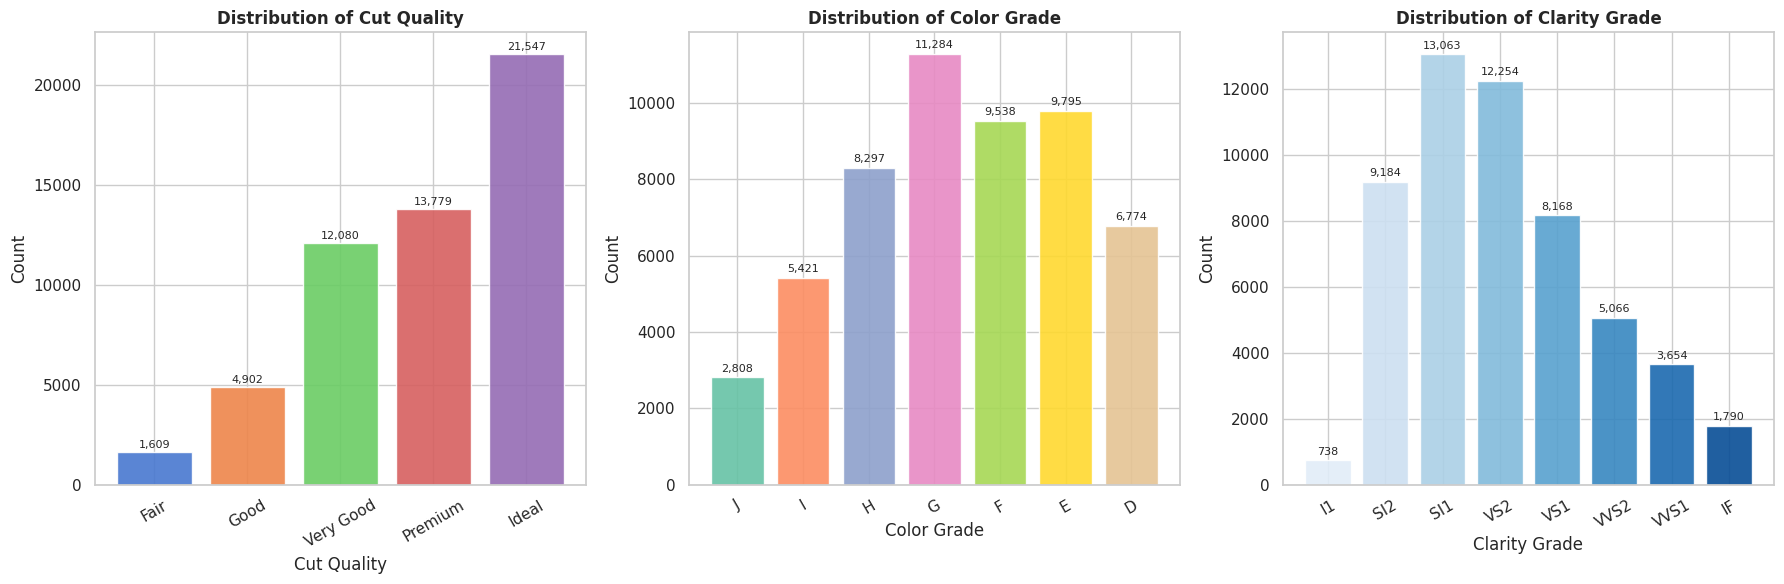

Category counts:

cut:
cut
Fair          1609
Good          4902
Very Good    12080
Premium      13779
Ideal        21547

color:
color
J     2808
I     5421
H     8297
G    11284
F     9538
E     9795
D     6774

clarity:
clarity
I1        738
SI2      9184
SI1     13063
VS2     12254
VS1      8168
VVS2     5066
VVS1     3654
IF       1790


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cat_info = [
    ('cut',     cut_order,     'Cut Quality',  'muted'),
    ('color',   color_order,   'Color Grade',  'Set2'),
    ('clarity', clarity_order, 'Clarity Grade','Blues'),
]

for i, (col, order, title, pal) in enumerate(cat_info):
    counts = df_clean[col].value_counts()[order]
    bars = axes[i].bar(counts.index, counts.values,
                       color=sns.color_palette(pal, len(order)),
                       edgecolor='white', alpha=0.9)
    axes[i].set_title(f'Distribution of {title}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(title)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                    f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figures/05_categorical_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

print('Category counts:')
for col, order, _, _ in cat_info:
    print(f'\n{col}:')
    print(df_clean[col].value_counts()[order].to_string())


### 7.5 Price Distributions by Quality Grades


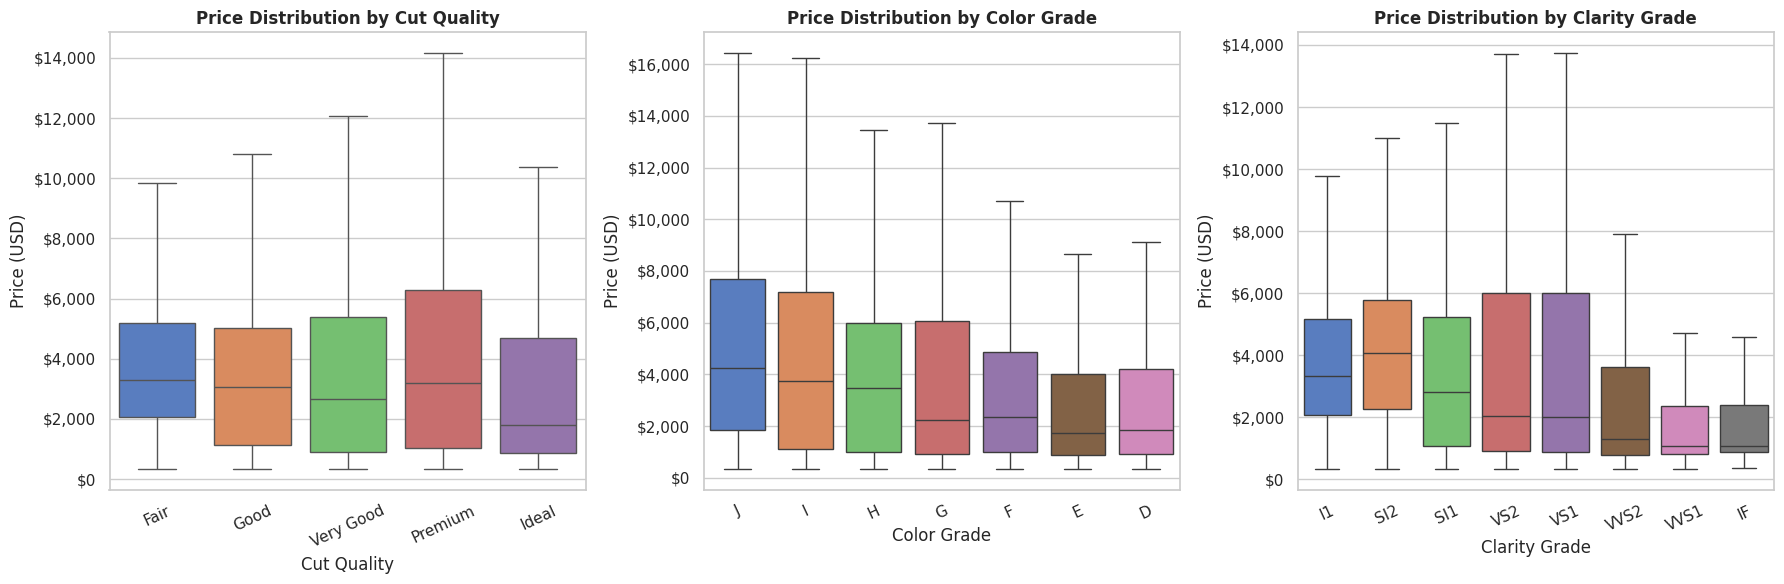

Key observation: Counter-intuitive patterns are visible — J color and
lower clarity grades can show higher median prices due to carat size confounding.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, order, title) in enumerate([
    ('cut',     cut_order,     'Cut Quality'),
    ('color',   color_order,   'Color Grade'),
    ('clarity', clarity_order, 'Clarity Grade'),
]):
    sns.boxplot(data=df_clean, x=col, y='price', order=order,
                palette='muted', ax=axes[i], showfliers=False)
    axes[i].set_title(f'Price Distribution by {title}',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel(title)
    axes[i].set_ylabel('Price (USD)')
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('figures/06_price_by_grades.png', bbox_inches='tight', dpi=150)
plt.show()

print('Key observation: Counter-intuitive patterns are visible — J color and')
print('lower clarity grades can show higher median prices due to carat size confounding.')


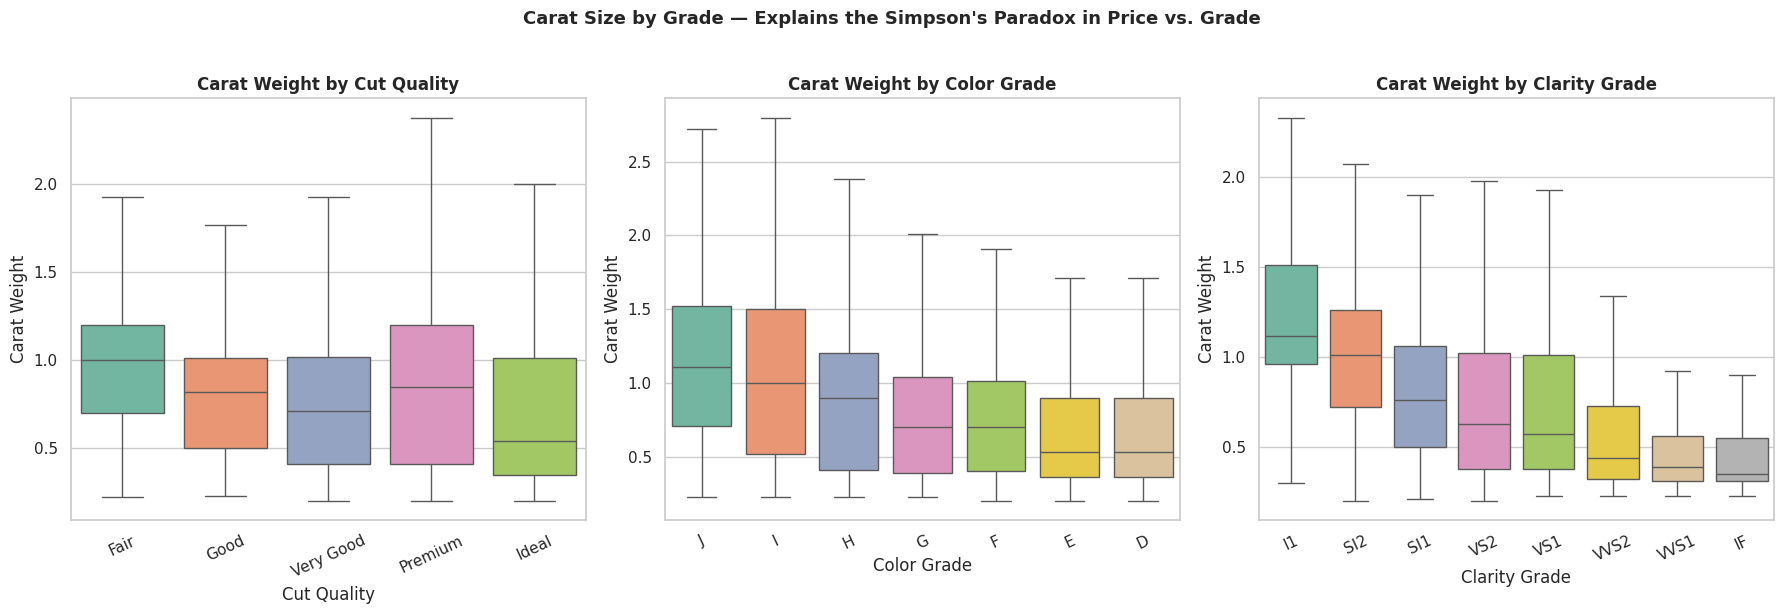

Insight: Lower-quality grades (J color, I1 clarity) tend to contain
LARGER carat stones, which is why their raw prices can appear higher.
This is a classic Simpson's Paradox — carat is a confounding variable.


In [16]:
# Visualise carat size by grade to explain the paradox
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, order, title) in enumerate([
    ('cut',     cut_order,     'Cut Quality'),
    ('color',   color_order,   'Color Grade'),
    ('clarity', clarity_order, 'Clarity Grade'),
]):
    sns.boxplot(data=df_clean, x=col, y='carat', order=order,
                palette='Set2', ax=axes[i], showfliers=False)
    axes[i].set_title(f'Carat Weight by {title}',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel(title)
    axes[i].set_ylabel('Carat Weight')
    axes[i].tick_params(axis='x', rotation=25)

plt.suptitle(
    'Carat Size by Grade — Explains the Simpson\'s Paradox in Price vs. Grade',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/07_carat_by_grades.png', bbox_inches='tight', dpi=150)
plt.show()

print('Insight: Lower-quality grades (J color, I1 clarity) tend to contain')
print('LARGER carat stones, which is why their raw prices can appear higher.')
print('This is a classic Simpson\'s Paradox — carat is a confounding variable.')


### 7.6 Outlier Analysis


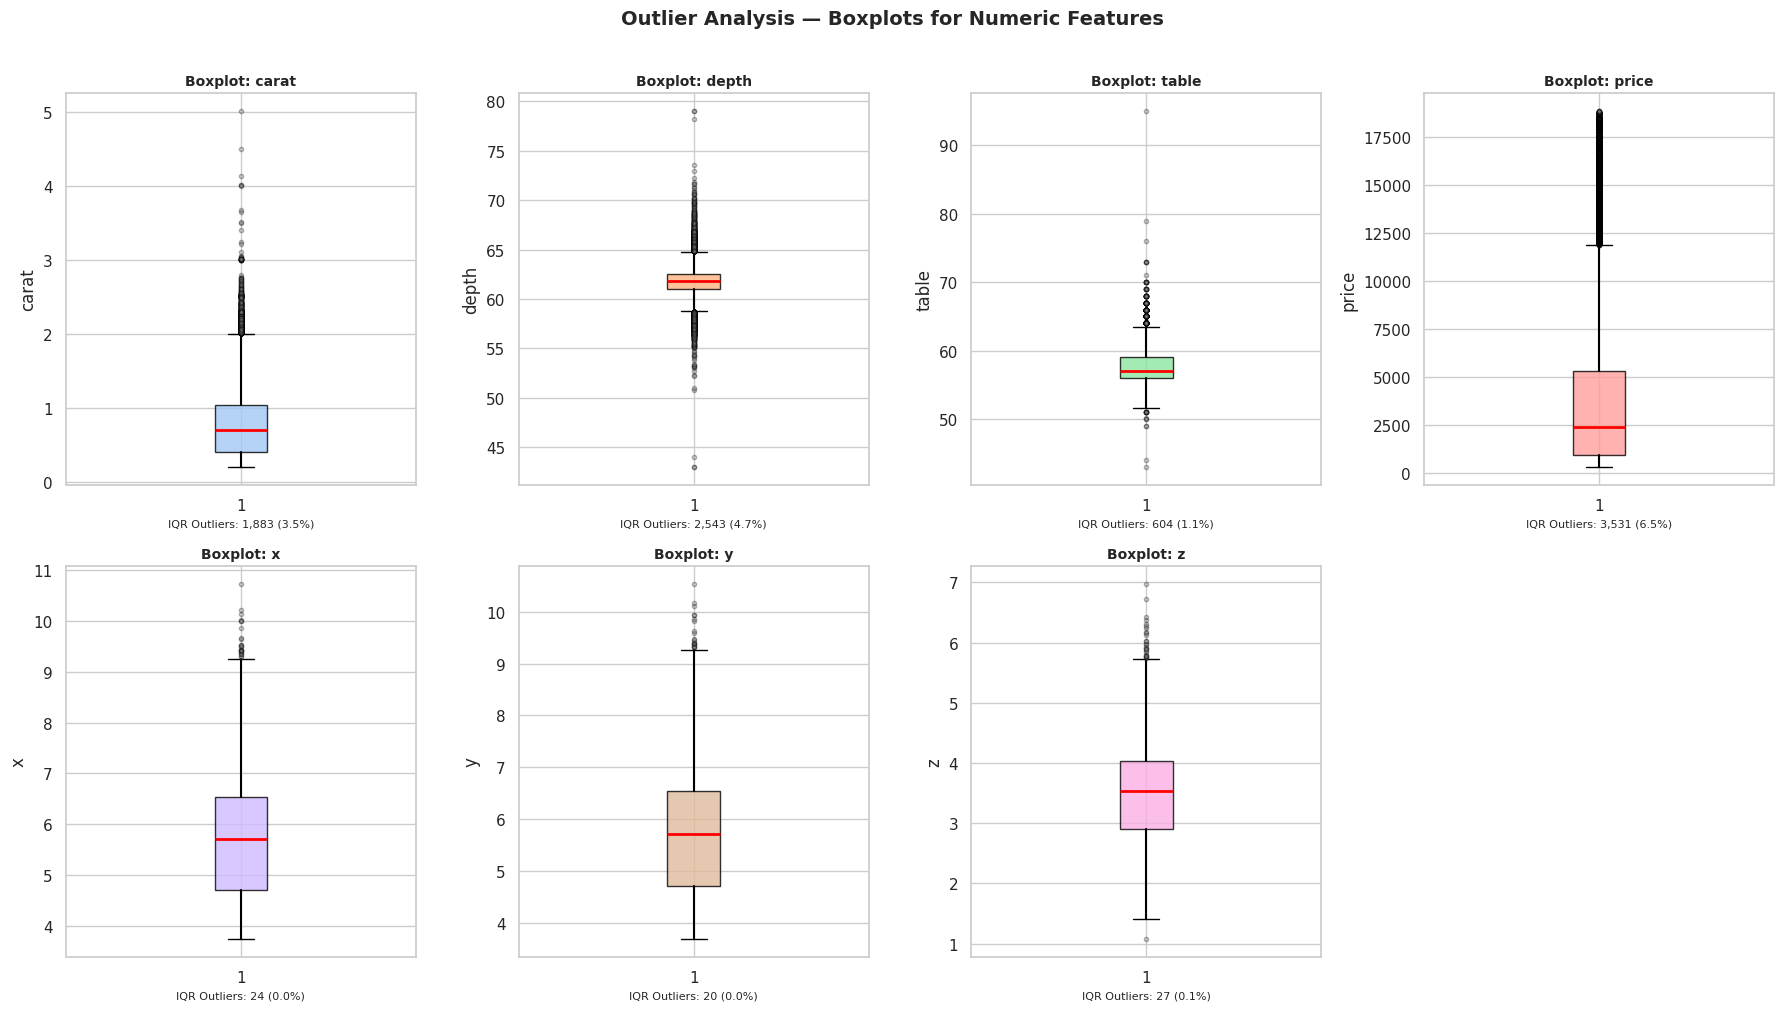

Outlier summary (IQR method):
  carat   : 1,883 outliers (3.5%)
  depth   : 2,543 outliers (4.7%)
  table   :   604 outliers (1.1%)
  price   : 3,531 outliers (6.5%)
  x       :    24 outliers (0.0%)
  y       :    20 outliers (0.0%)
  z       :    27 outliers (0.1%)


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
palette = sns.color_palette('pastel', 7)

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(
        df_clean[col],
        patch_artist=True,
        boxprops=dict(facecolor=palette[i], alpha=0.8),
        whiskerprops=dict(linewidth=1.5),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.3)
    )
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1-1.5*IQR) | (df_clean[col] > Q3+1.5*IQR)).sum()
    axes[i].set_title(f'Boxplot: {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].set_xlabel(
        f'IQR Outliers: {n_out:,} ({n_out/len(df_clean)*100:.1f}%)', fontsize=8)

axes[-1].set_visible(False)

plt.suptitle('Outlier Analysis — Boxplots for Numeric Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/08_outlier_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('Outlier summary (IQR method):')
for col in numeric_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = ((df_clean[col] < Q1-1.5*IQR) | (df_clean[col] > Q3+1.5*IQR)).sum()
    print(f'  {col:<8}: {n:>5,} outliers ({n/len(df_clean)*100:.1f}%)')


## 8. Key Findings & Insights

### Summary of EDA Findings


In [18]:
print('=' * 65)
print('KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS')
print('=' * 65)

print(f'\n DATASET OVERVIEW')
print(f'  Total records (cleaned): {len(df_clean):,}')
print(f'  Features:                {df_clean.shape[1]}')
print(f'  Target variable:         price (USD)')
print(f'  Price range:             ${df_clean["price"].min():,} — ${df_clean["price"].max():,}')

carat_corr = df_clean['carat'].corr(df_clean['price'])
print(f'\n 1. CARAT IS THE DOMINANT PREDICTOR')
print(f'    carat vs price: r = {carat_corr:.3f}')
print(f'    Physical dimensions (x, y, z) are nearly perfectly correlated with carat.')

print(f'\n 2. SIMPSONS PARADOX IN QUALITY GRADES')
j_price  = df_clean[df_clean['color'] == 'J']['price'].median()
d_price  = df_clean[df_clean['color'] == 'D']['price'].median()
j_carat  = df_clean[df_clean['color'] == 'J']['carat'].median()
d_carat  = df_clean[df_clean['color'] == 'D']['carat'].median()
print(f'    J color (worst) median price: ${j_price:,}  (median carat: {j_carat:.2f})')
print(f'    D color (best)  median price: ${d_price:,}  (median carat: {d_carat:.2f})')
print(f'    Lower quality grades contain larger carat stones, confounding raw price comparisons.')

depth_corr = df_clean['depth'].corr(df_clean['price'])
table_corr = df_clean['table'].corr(df_clean['price'])
print(f'\n 3. DEPTH & TABLE HAVE MINIMAL PRICE IMPACT')
print(f'    depth vs price: r = {depth_corr:.4f}')
print(f'    table vs price: r = {table_corr:.4f}')
print(f'    These proportional measurements have near-zero correlation with price.')

print(f'\n 4. RIGHT-SKEWED PRICE DISTRIBUTION')
print(f'    Raw price skewness:          {df_clean["price"].skew():.4f}')
print(f'    log(price) skewness:         {np.log1p(df_clean["price"]).skew():.4f}')
print(f'    Log transformation yields a near-normal distribution — preferred for modelling.')

ideal_pct = (df_clean['cut'] == 'Ideal').mean() * 100
print(f'\n 5. IDEAL CUT IS THE MOST COMMON GRADE')
print(f'    {ideal_pct:.1f}% of diamonds in the dataset have an Ideal cut.')
print(f'    Fair cut is the rarest ({(df_clean["cut"]=="Fair").mean()*100:.1f}%).')


KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS

 DATASET OVERVIEW
  Total records (cleaned): 53,917
  Features:                13
  Target variable:         price (USD)
  Price range:             $326 — $18,823

 1. CARAT IS THE DOMINANT PREDICTOR
    carat vs price: r = 0.922
    Physical dimensions (x, y, z) are nearly perfectly correlated with carat.

 2. SIMPSONS PARADOX IN QUALITY GRADES
    J color (worst) median price: $4,234.0  (median carat: 1.11)
    D color (best)  median price: $1,836.5  (median carat: 0.53)
    Lower quality grades contain larger carat stones, confounding raw price comparisons.

 3. DEPTH & TABLE HAVE MINIMAL PRICE IMPACT
    depth vs price: r = -0.0107
    table vs price: r = 0.1272
    These proportional measurements have near-zero correlation with price.

 4. RIGHT-SKEWED PRICE DISTRIBUTION
    Raw price skewness:          1.6184
    log(price) skewness:         0.1161
    Log transformation yields a near-normal distribution — preferred for modelling.

 5.

## 9. Baseline Model


In [19]:
# Ordinal encoding for categorical features
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

enc = OrdinalEncoder(
    categories=[cut_order, color_order, clarity_order],
    handle_unknown='use_encoded_value', unknown_value=-1
)

df_model = df_clean.copy()
df_model[['cut_enc', 'color_enc', 'clarity_enc']] = enc.fit_transform(
    df_model[['cut', 'color', 'clarity']]
)

model_features = ['carat', 'cut_enc', 'color_enc', 'clarity_enc',
                   'depth', 'table', 'x', 'y', 'z']
X = df_model[model_features]
y = np.log1p(df_model['price'])   # log-transform target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_log = lr.predict(X_test_s)

# Back-transform for interpretable metrics
y_pred_price = np.expm1(y_pred_log)
y_test_price = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
mae  = mean_absolute_error(y_test_price, y_pred_price)
r2   = r2_score(y_test, y_pred_log)  # R² on log scale

print('=' * 55)
print('BASELINE LINEAR REGRESSION RESULTS (log-price)')
print('=' * 55)
print(f'Training samples:     {len(X_train):,}')
print(f'Test samples:         {len(X_test):,}')
print()
print(f'R² Score (log-price): {r2:.4f}')
print(f'RMSE (USD):           ${rmse:,.0f}')
print(f'MAE  (USD):           ${mae:,.0f}')
print()
print(f'Interpretation:')
print(f'  The model explains {r2*100:.1f}% of variance in log-price.')
print(f'  Average prediction error: ~${rmse:,.0f}')


BASELINE LINEAR REGRESSION RESULTS (log-price)
Training samples:     43,133
Test samples:         10,784

R² Score (log-price): 0.9791
RMSE (USD):           $867
MAE  (USD):           $455

Interpretation:
  The model explains 97.9% of variance in log-price.
  Average prediction error: ~$867


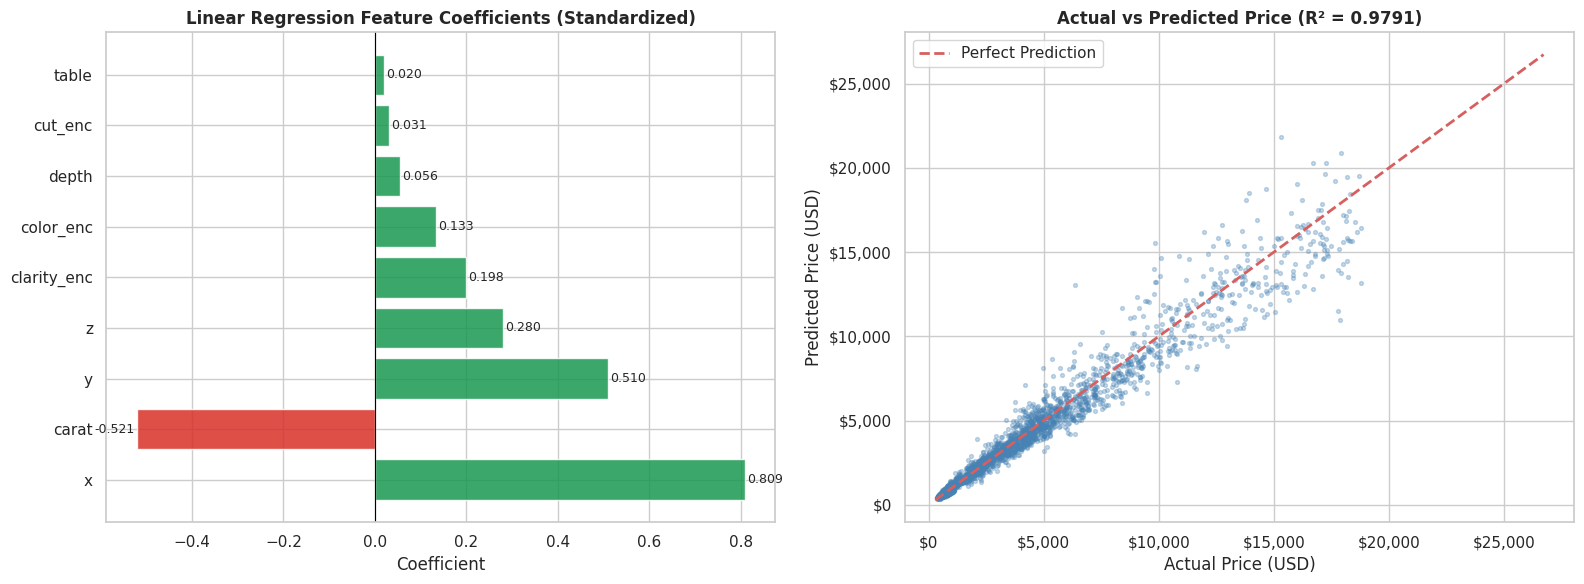

Feature importance (by absolute coefficient):
    Feature  Coefficient
          x       0.8090
      carat      -0.5211
          y       0.5095
          z       0.2798
clarity_enc       0.1982
  color_enc       0.1327
      depth       0.0555
    cut_enc       0.0307
      table       0.0204


In [20]:
coef_df = pd.DataFrame({
    'Feature':     model_features,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficient bar chart
colors = ['#1a9850' if c > 0 else '#d73027' for c in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=colors, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Linear Regression Feature Coefficients (Standardized)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient')
for idx, coef in enumerate(coef_df['Coefficient']):
    offset = 0.005 if coef >= 0 else -0.005
    ha = 'left' if coef >= 0 else 'right'
    axes[0].text(coef + offset, idx, f'{coef:.3f}',
                va='center', ha=ha, fontsize=9)

# Actual vs Predicted
sample_idx = np.random.choice(len(y_test_price), 3000, replace=False)
axes[1].scatter(y_test_price.iloc[sample_idx], y_pred_price[sample_idx],
               alpha=0.3, s=8, color='steelblue')
lo = min(y_test_price.min(), y_pred_price.min())
hi = max(y_test_price.max(), y_pred_price.max())
axes[1].plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title(f'Actual vs Predicted Price (R\u00b2 = {r2:.4f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/09_baseline_model.png', bbox_inches='tight', dpi=150)
plt.show()

print('Feature importance (by absolute coefficient):')
print(coef_df.to_string(index=False))


## 10. Next Steps

Based on the EDA findings, the following steps are planned for the full capstone:

### Model Improvements
1. **Non-Linear Models**: Implement Random Forest, Gradient Boosting (XGBoost/LightGBM) to capture the non-linear interaction between carat weight and price.
2. **Feature Engineering**: Create derived features such as `volume = x * y * z`, `carat_per_depth`, and polynomial terms for carat.
3. **Log-Transformed Target**: Continue using `log1p(price)` — it significantly improves model performance and reduces the impact of price outliers.
4. **Interaction Terms**: Explore carat × clarity and carat × color interactions to capture the compounding effect of size and quality on price.

### Robust Evaluation
5. **k-Fold Cross-Validation**: Use 5-fold CV for reliable generalization estimates.
6. **Hyperparameter Tuning**: Apply GridSearchCV for tree-based models.
7. **Residual Analysis**: Inspect residuals by carat bucket and grade to identify systematic model errors.

### Analysis Extensions
8. **SHAP Analysis**: Apply SHAP values to explain individual predictions and quantify feature contributions.
9. **Market Segmentation**: Cluster diamonds by carat/quality profile to identify distinct market segments.
10. **Price Recommendation Tool**: Build an interactive Streamlit app that predicts a fair market price for user-specified diamond attributes.

---

## References

- Wickham, H. (2016). *ggplot2: Elegant Graphics for Data Analysis.* Springer. (Source of the Diamonds dataset)
- GIA (Gemological Institute of America). *The 4Cs of Diamond Quality.* https://www.gia.edu/gia-about/4Cs
- Pedregosa et al. *Scikit-learn: Machine Learning in Python.* JMLR 12, pp. 2825-2830, 2011.

---
*Capstone Assignment 20.1 | UC Berkeley Professional Certificate in ML & AI*
